In [60]:
#!pip install yfinance

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import bs4 as bs
import requests
import seaborn as sns

In [2]:
# Pegando todos os tickers do S&P500
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"
}

resp = requests.get(url, headers=headers)
soup = bs.BeautifulSoup(resp.text, "lxml")

table = soup.find("table", {"id": "constituents"})  # tabela principal
tickers = []
for row in table.find_all("tr")[1:]:
    ticker = row.find_all("td")[0].text.strip()
    tickers.append(ticker)

print(len(tickers))
tickers[:10]

503


['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']

In [3]:
soup

<!DOCTYPE html>
<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 vector-feature-night-mode-enabled skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available" dir="ltr" lang="en">
<head>
<meta charset="utf-8"/>
<title>List of S&amp;P 500 companies - Wikipedia</title>
<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-ena

In [4]:
# Salvar para uso futuro
# data.to_csv("dados_2006_2007.csv")
# data_full.to_csv("dados_full_1997_2007.csv")

# Carregar de volta os DataFrames
data = pd.read_csv("dados_2006_2007.csv", index_col=0)
data_full = pd.read_csv("dados_full_1997_2007.csv", index_col=0)

data.head()

,MMM,AOS,ABT,ACN,ADBE,AMD,AES,AFL,A,APD,...,WDC,WY,WSM,WMB,WTW,WYNN,XEL,YUM,ZBRA,ZBH
Date,,,,,,,,,,,,,,,,,,,,,
2006-01-03,37.081547,4.466237,12.043580,20.727745,38.520000,32.400002,10.594819,14.750942,20.099953,34.221111,...,11.519893,12.624354,13.915199,8.324626,62.774403,29.063988,9.076958,11.604428,42.830002,59.318142
2006-01-04,36.894047,4.490475,12.061859,20.840939,38.419998,32.560001,11.046078,14.833289,20.153952,33.830730,...,11.907521,12.929356,13.615329,8.376873,63.426319,29.010126,9.120948,11.703718,42.410000,59.881184
2006-01-05,36.556564,4.448058,12.217154,20.996572,38.070000,33.680000,10.941437,14.953654,20.681948,33.537956,...,11.792443,12.815689,13.455826,8.289795,62.465599,28.837723,9.116060,12.202649,42.529999,59.248859
2006-01-06,36.856556,4.600766,12.451633,22.036497,39.000000,33.779999,11.118017,15.488960,20.789949,34.318707,...,12.052884,12.834638,13.551526,8.321140,61.710732,29.112476,9.150272,12.167892,44.119999,58.945667
2006-01-09,37.039375,4.757120,12.914498,21.972824,38.380001,33.250000,10.928357,15.561815,20.729950,33.882404,...,12.803917,12.804320,13.889683,8.456982,64.215515,30.486214,9.125832,12.262219,44.790001,61.033234


In [36]:
# Baixar dados históricos

# substituir 'BRK.B' por 'BRK-B' )em todos os casos)
# def download_one_ticker(ticker, start, end, max_retries=3, delay=5):
#     for attempt in range(max_retries):
#         try:
#             sanitized = ticker.replace(".", "-")
#             df = yf.download(sanitized, start=start, end=end, auto_adjust=True,
#                              progress=False, threads=False, timeout=30)
            
#             if not df.empty:
#                 return df["Close"]
#             else:
#                 return None
                
#         except Exception as e:
#             err_msg = str(e)
#             print(err_msg)
            
#             # Outros erros → re-tenta
#             time.sleep(delay)

#     return None

# start_date_full = "1997-01-02"
# start_date = "2006-01-02"
# end_date = "2007-12-31"

# dict_data = {}
# dict_data_full = {}
# data_fail = []
# data_full_fail = []

# for ticker in tickers:
#     data_ticker = download_one_ticker(ticker, start_date, end_date)
#     print(ticker)
#     if data_ticker is not None:
#         dict_data[ticker] = data_ticker
#     else:
#         data_fail.append(ticker)

#     data_ticker_full = download_one_ticker(ticker, start_date_full, end_date)
#     if data_ticker_full is not None:
#         dict_data_full[ticker] = data_ticker_full
#     else:
#         data_full_fail.append(ticker)

# # Construir DataFrames
# data = pd.concat(dict_data.values(), axis=1)
# data.columns = dict_data.keys()

# data_full = pd.concat(dict_data_full.values(), axis=1)
# data_full.columns = dict_data_full.keys()
# data.head()

# Salvar para uso futuro
# data.to_csv("dados_2006_2007.csv")
# data_full.to_csv("dados_full_1997_2007.csv")

In [7]:
data_full.head()

,MMM,AOS,ABT,ACN,ADBE,AMD,AES,AFL,A,APD,...,WDC,WY,WSM,WMB,WTW,WYNN,XEL,YUM,ZBRA,ZBH
Date,,,,,,,,,,,,,,,,,,,,,
1997-01-02,16.557709,1.968470,5.582990,NaN,4.734613,13.5625,7.418825,3.155399,NaN,16.411489,...,16.618141,6.832460,2.766412,4.945474,NaN,NaN,6.785945,NaN,10.333333,NaN
1997-01-03,16.269743,1.951928,5.707671,NaN,4.795901,14.0000,7.398387,3.164598,NaN,16.682501,...,17.337374,6.832460,2.871085,5.030447,NaN,NaN,6.804490,NaN,10.722222,NaN
1997-01-06,16.293741,1.927115,5.638408,NaN,4.964447,14.2500,7.602762,3.201396,NaN,16.772846,...,18.094473,6.923078,2.701612,5.098428,NaN,NaN,6.841568,NaN,10.888889,NaN
1997-01-07,16.101768,1.985012,5.763087,NaN,5.163639,14.9375,7.684513,3.182998,NaN,16.712626,...,18.018761,7.013694,2.781365,5.200395,NaN,NaN,6.878652,NaN,11.888889,NaN
1997-01-08,16.077768,1.976742,5.679967,NaN,5.178962,14.4375,7.745826,3.201396,NaN,16.802954,...,18.737993,7.068064,2.721551,5.251381,NaN,NaN,6.952816,NaN,11.666667,NaN


In [9]:
start_date_full = "1997-01-02"
start_date = "2006-01-02"
end_date = "2007-12-31"

data_spy = yf.download("SPY", start=start_date, end=end_date, auto_adjust=True)["Close"]
data_spy_full = yf.download("SPY", start=start_date_full, end=end_date, auto_adjust=True)["Close"]

data_spy.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Ticker,SPY
Date,
2006-01-03,87.964890
2006-01-04,88.381462
2006-01-05,88.437027
2006-01-06,89.172966
2006-01-09,89.402077


In [10]:
# Calcular retornos diários
returns = data.pct_change()
returns.dropna(inplace=True,axis=0, how='all')
returns.dropna(inplace=True,axis=1, how='any')

returns_full = data_full.pct_change()
returns_full.dropna(inplace=True,axis=0, how='all')
returns_full.dropna(inplace=True,axis=1, how='any')

returns_spy = data_spy.pct_change()
returns_spy.dropna(inplace=True,axis=0, how='all')
returns_spy.dropna(inplace=True,axis=1, how='any')

returns_spy_full = data_spy_full.pct_change()
returns_spy_full.dropna(inplace=True,axis=0, how='all')
returns_spy_full.dropna(inplace=True,axis=1, how='any')

returns.head()

,MMM,AOS,ABT,ACN,ADBE,AMD,AES,AFL,A,APD,...,WDC,WY,WSM,WMB,WTW,WYNN,XEL,YUM,ZBRA,ZBH
Date,,,,,,,,,,,,,,,,,,,,,
2006-01-04,-0.005056,0.005427,0.001518,0.005461,-0.002596,0.004938,0.042592,0.005582,0.002687,-0.011408,...,0.033649,0.024160,-0.021550,0.006276,0.010385,-0.001853,0.004846,0.008556,-0.009806,0.009492
2006-01-05,-0.009147,-0.009446,0.012875,0.007468,-0.009110,0.034398,-0.009473,0.008115,0.026198,-0.008654,...,-0.009664,-0.008791,-0.011715,-0.010395,-0.015147,-0.005943,-0.000536,0.042630,0.002829,-0.010560
2006-01-06,0.008206,0.034332,0.019193,0.049528,0.024429,0.002969,0.016139,0.035798,0.005222,0.023280,...,0.022085,0.001479,0.007112,0.003781,-0.012085,0.009528,0.003753,-0.002848,0.037385,-0.005117
2006-01-09,0.004960,0.033984,0.037173,-0.002889,-0.015897,-0.015690,-0.017059,0.004704,-0.002886,-0.012713,...,0.062311,-0.002362,0.024953,0.016325,0.040589,0.047187,-0.002671,0.007752,0.015186,0.035415
2006-01-10,-0.006201,0.023948,-0.009668,-0.021571,0.005993,0.050526,-0.006583,0.000814,0.013025,-0.011522,...,0.008988,0.013316,0.019062,0.008649,-0.010152,0.001237,0.004821,-0.000810,0.037285,-0.004257


In [11]:
returns_full.head()

,MMM,AOS,ABT,ADBE,AMD,AES,AFL,APD,ALB,LNT,...,WEC,WFC,WELL,WST,WDC,WY,WSM,WMB,XEL,ZBRA
Date,,,,,,,,,,,,,,,,,,,,,
1997-01-03,-0.017392,-0.008404,0.022332,0.012945,0.032258,-0.002755,0.002915,0.016514,-0.019608,0.004464,...,0.004672,0.020231,0.015544,-0.004465,0.043280,0.000000,0.037837,0.017182,0.002733,0.037634
1997-01-06,0.001475,-0.012712,-0.012135,0.035144,0.017857,0.027624,0.011628,0.005416,0.020000,0.004445,...,0.004651,-0.011332,-0.005102,-0.004484,0.043669,0.013263,-0.059027,0.013514,0.005449,0.015544
1997-01-07,-0.011782,0.030044,0.022112,0.040124,0.048246,0.010753,-0.005747,-0.003590,-0.006536,-0.004426,...,0.000000,0.011462,-0.010257,0.009009,-0.004184,0.013089,0.029520,0.020000,0.005420,0.091837
1997-01-08,-0.001491,-0.004166,-0.014423,0.002967,-0.033473,0.007979,0.005780,0.005405,-0.019737,0.000000,...,0.009260,0.005665,-0.010363,-0.008929,0.039916,0.007752,-0.021505,0.009804,0.010782,-0.018692
1997-01-09,-0.001492,-0.004185,0.009756,-0.020710,-0.047619,0.002639,-0.008620,-0.001792,0.013423,0.004445,...,0.018348,0.000000,0.020943,0.000000,0.020202,-0.002564,0.069597,0.019417,0.002666,0.038095


In [13]:
display(returns.mean())
returns.std()

MMM     0.000308
AOS     0.000229
ABT     0.000904
ACN     0.000624
ADBE    0.000380
          ...   
WYNN    0.002061
XEL     0.000637
YUM     0.001165
ZBRA   -0.000277
ZBH     0.000058
Length: 401, dtype: float64

MMM     0.011614
AOS     0.021684
ABT     0.011357
ACN     0.015595
ADBE    0.018172
          ...   
WYNN    0.024934
XEL     0.011289
YUM     0.014912
ZBRA    0.016741
ZBH     0.015221
Length: 401, dtype: float64

In [17]:
# Padronização dos retornos
mu_i = returns.mean()
sigma_i = returns.std()
Y = (returns - mu_i)/sigma_i

Y_full = (returns_full - returns_full.mean())/returns_full.std()
Y.head()

,MMM,AOS,ABT,ACN,ADBE,AMD,AES,AFL,A,APD,...,WDC,WY,WSM,WMB,WTW,WYNN,XEL,YUM,ZBRA,ZBH
Date,,,,,,,,,,,,,,,,,,,,,
2006-01-04,-0.461896,0.239724,0.054039,0.310138,-0.163758,0.266527,2.475828,0.360259,0.126837,-0.926943,...,1.313270,1.450894,-1.016633,0.317457,0.891273,-0.156965,0.372922,0.495690,-0.569213,0.619747
2006-01-05,-0.814139,-0.446166,1.054029,0.438813,-0.522195,1.312046,-0.602969,0.548340,1.487018,-0.724983,...,-0.440291,-0.566731,-0.535169,-0.690962,-1.347428,-0.320986,-0.103860,2.780748,0.185557,-0.697578
2006-01-06,0.680067,1.572703,1.610313,3.135792,1.323373,0.196640,0.911538,2.604647,0.273520,1.617231,...,0.845123,0.062104,0.386508,0.166538,-1.078903,0.299475,0.276063,-0.269116,2.249678,-0.340030
2006-01-09,0.400580,1.556687,3.193479,-0.225300,-0.895706,-0.465556,-1.051534,0.294981,-0.195540,-1.022707,...,2.473709,-0.173065,1.259919,0.925284,3.539619,1.809863,-0.293005,0.441767,0.923640,2.322822
2006-01-10,-0.560452,1.093870,-0.930821,-1.423187,0.308870,1.884436,-0.432051,0.006035,0.724913,-0.935307,...,0.314867,0.786905,0.971516,0.460980,-0.909466,-0.033023,0.370669,-0.132394,2.243686,-0.283538


In [19]:
# Calculando a matriz de correlação
corr_matrix = Y.corr()
corr_matrix_full = Y_full.corr()

corr_matrix.head()

,MMM,AOS,ABT,ACN,ADBE,AMD,AES,AFL,A,APD,...,WDC,WY,WSM,WMB,WTW,WYNN,XEL,YUM,ZBRA,ZBH
MMM,1.000000,0.233617,0.247571,0.208133,0.242899,0.175018,0.253134,0.336263,0.376592,0.439362,...,0.236256,0.374132,0.298393,0.272085,0.198557,0.236656,0.314490,0.299764,0.254543,0.203040
AOS,0.233617,1.000000,0.208440,0.265484,0.200147,0.203088,0.215254,0.233832,0.228673,0.347640,...,0.275472,0.371026,0.287917,0.235934,0.201353,0.218884,0.263169,0.289694,0.254592,0.172078
ABT,0.247571,0.208440,1.000000,0.224952,0.200951,0.144943,0.257341,0.388112,0.280268,0.364761,...,0.192838,0.340282,0.200823,0.182500,0.168157,0.242759,0.430465,0.294047,0.178662,0.175148
ACN,0.208133,0.265484,0.224952,1.000000,0.195496,0.177215,0.217893,0.263745,0.276139,0.289136,...,0.177004,0.270910,0.196648,0.196379,0.160663,0.202362,0.134653,0.239479,0.225472,0.179566
ADBE,0.242899,0.200147,0.200951,0.195496,1.000000,0.254135,0.199261,0.315688,0.303718,0.374555,...,0.196084,0.233678,0.195029,0.204273,0.177361,0.201448,0.274755,0.258044,0.258183,0.212827


array([119.16582534,  11.988182  ,  10.60121618,   8.2126816 ,
         6.06003598,   4.96473214,   4.27049877,   4.03857861,
         3.4335363 ,   3.21305215,   2.99207894,   2.91899816,
         2.68161858,   2.60773627,   2.57561032,   2.50523205,
         2.42227784,   2.37420199,   2.30288216,   2.26888953])

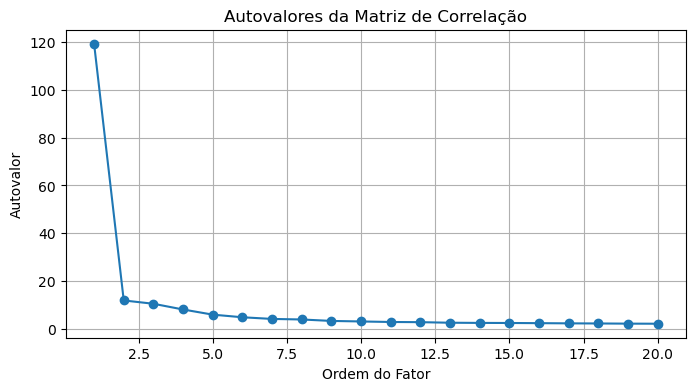

In [20]:
# PCA sobre matriz de correlação empírica
evals, evecs = np.linalg.eigh(corr_matrix)         
idx = np.argsort(evals)[::-1]                      
eigen_val  = evals[idx]
eigen_vec  = evecs[:, idx]                          

evals_f, evecs_f = np.linalg.eigh(corr_matrix_full)
idx_f = np.argsort(evals_f)[::-1]
eigen_val_full = evals_f[idx_f]
eigen_vec_full = evecs_f[:, idx_f]

display(eigen_val[:20])

# --- Visualização dos 20 maiores autovalores
plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, min(20, len(eigen_val)) + 1), eigen_val[:20], 'o-')
plt.title("Autovalores da Matriz de Correlação")
plt.xlabel("Ordem do Fator")
plt.ylabel("Autovalor")
plt.grid(True)
plt.show()


(0.5, 25.0)

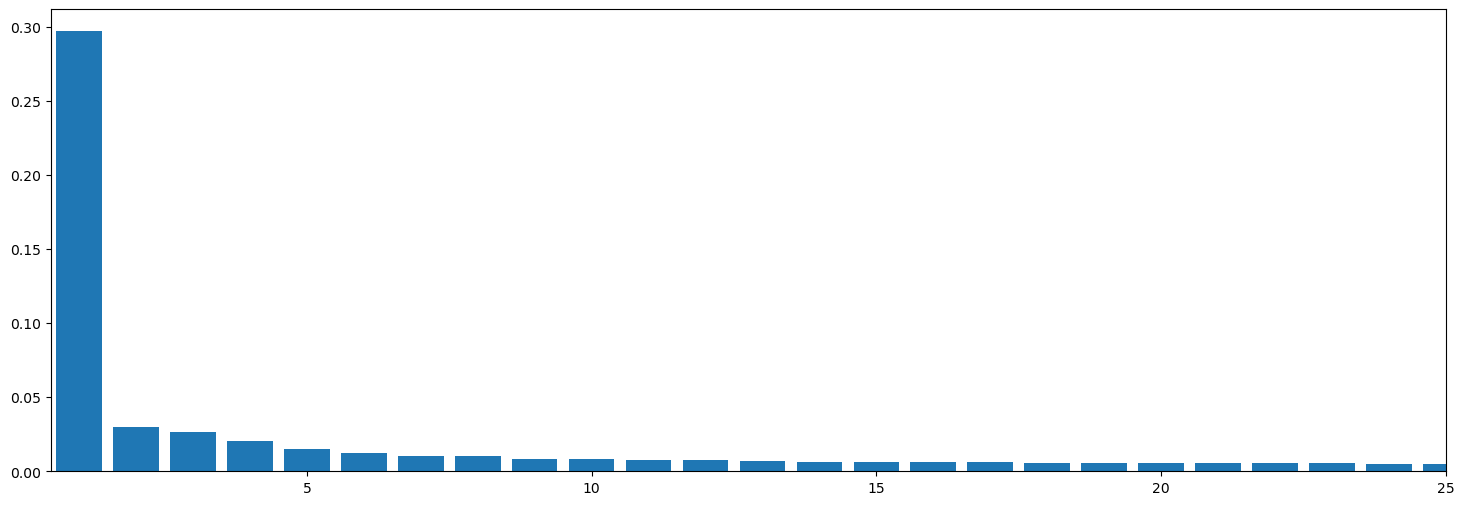

In [21]:
plt.figure(figsize=(18,6))
plt.bar(np.arange(1, len(eigen_val)+1),height = (eigen_val)/sum(eigen_val))
plt.xlim(0.5,25)
#plt.ylim(0,0.7)

In [23]:
# Pesos dos eigenportfólios
sigma = returns.std(ddof=1)
sigma_full = returns_full.std(ddof=1)

def eigen_weights(j):
    vj = pd.Series(eigen_vec[:, j], index=returns.columns)
    wj = vj / sigma
    wj = wj / wj.abs().sum()     # |w|=1 (controle de alavancagem)
    return wj

def eigen_weights_full(j):
    vj = pd.Series(eigen_vec_full[:, j], index=returns_full.columns)
    wj = vj / sigma_full
    wj = wj / wj.abs().sum()
    return wj

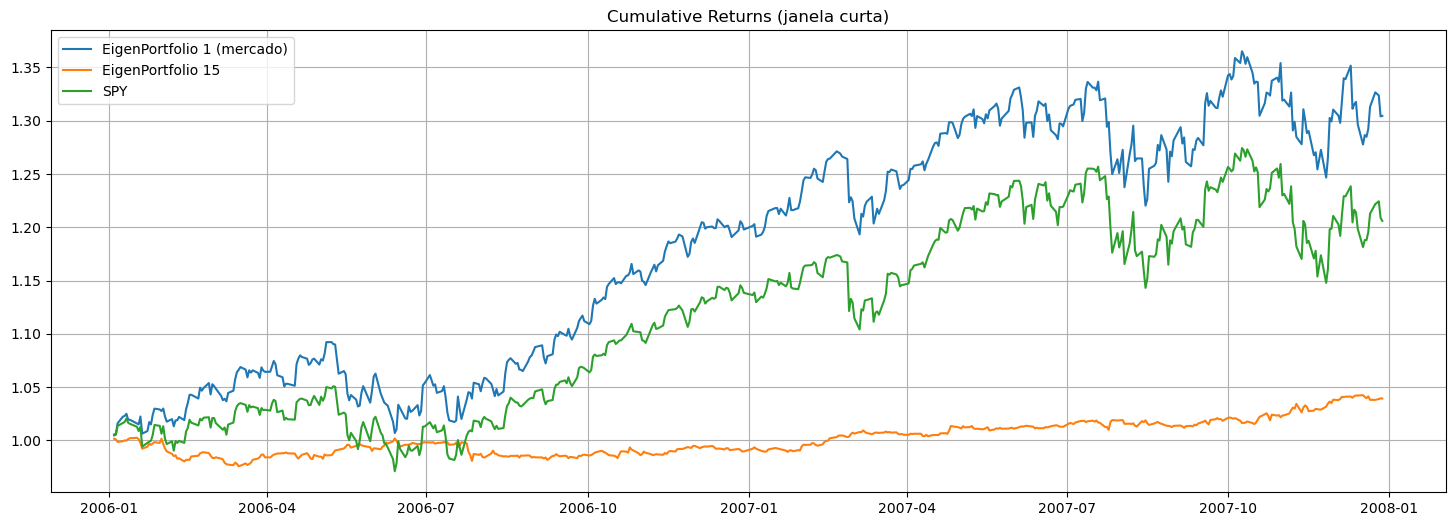

In [27]:
# Pesos do Eigenportifolio de mercado
w1  = eigen_weights(0)    # PC1 ~ "mercado"
w15 = eigen_weights(14)   # PC15

# --- Retornos diários dos fatores ---
F1  = returns.dot(w1) 
F15 = returns.dot(w15)

# --- Retornos acumulados
cum_F1  = (1 + F1).cumprod()
cum_F15 = (1 + F15).cumprod()
cum_SPY = (1 + returns_spy).cumprod()

if isinstance(cum_SPY, pd.DataFrame):
    # tente pelo rótulo; ajuste conforme seu DF
    cum_SPY = cum_SPY['SPY'] if 'SPY' in cum_SPY.columns else cum_SPY.iloc[:, 0]

# --- Garantir DatetimeIndex sem timezone ---
for s in (cum_F1, cum_F15, cum_SPY):
    s.index = pd.to_datetime(s.index).tz_localize(None)
    
# --- Plot ---
plt.figure(figsize=(18,6))
plt.plot(cum_F1,  label='EigenPortfolio 1 (mercado)')
plt.plot(cum_F15, label='EigenPortfolio 15')
plt.plot(cum_SPY, label='SPY')
plt.legend(); plt.grid(True); plt.title('Cumulative Returns (janela curta)')
plt.show()

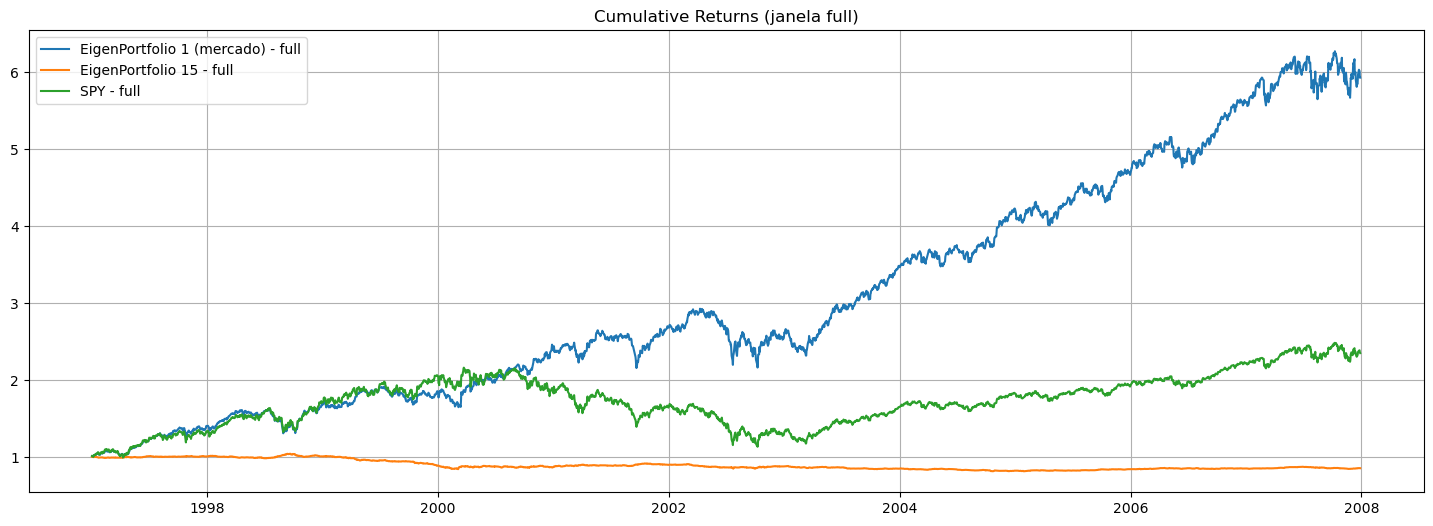

In [31]:
w1_full  = eigen_weights_full(0)
w15_full = eigen_weights_full(14)

F1_full  = returns_full.dot(w1_full)
F15_full = returns_full.dot(w15_full)

cum_F1_full  = (1 + F1_full).cumprod()
cum_F15_full = (1 + F15_full).cumprod()
cum_SPY_full = (1 + returns_spy_full).cumprod()

if isinstance(cum_SPY_full, pd.DataFrame):
    # tente pelo rótulo; ajuste conforme seu DF
    cum_SPY_full = cum_SPY_full['SPY'] if 'SPY' in cum_SPY_full.columns else cum_SPY_full.iloc[:, 0]

# --- Garantir DatetimeIndex sem timezone ---
for s in (cum_F1_full, cum_F15_full, cum_SPY_full):
    s.index = pd.to_datetime(s.index).tz_localize(None)
    
plt.figure(figsize=(18,6))
plt.plot(cum_F1_full,  label='EigenPortfolio 1 (mercado) - full')
plt.plot(cum_F15_full, label='EigenPortfolio 15 - full')
plt.plot(cum_SPY_full, label='SPY - full')
plt.legend(); plt.grid(True); plt.title('Cumulative Returns (janela full)')
plt.show()

Modelo contínuo com $m = 15 $ : $$
\frac{dS_i(t)}{S_i(t)} = \sum_{j=1}^m \beta_{ij} F_j(t) + dX_i(t)
$$

Esse modelo :

* Estima os betas de cada ativo com relação aos fatores

* Extrae os resíduos da regressão, que serão modelados como processo OU

* Calcula os parâmetros do OU: velocidade de reversão (κ), média de longo prazo (m), volatilidade (σ)

* Constroi sinais de reversão à média (s-score) com base nisso

In [29]:
data.head()

,MMM,AOS,ABT,ACN,ADBE,AMD,AES,AFL,A,APD,...,WDC,WY,WSM,WMB,WTW,WYNN,XEL,YUM,ZBRA,ZBH
Date,,,,,,,,,,,,,,,,,,,,,
2006-01-03,37.081547,4.466237,12.043580,20.727745,38.520000,32.400002,10.594819,14.750942,20.099953,34.221111,...,11.519893,12.624354,13.915199,8.324626,62.774403,29.063988,9.076958,11.604428,42.830002,59.318142
2006-01-04,36.894047,4.490475,12.061859,20.840939,38.419998,32.560001,11.046078,14.833289,20.153952,33.830730,...,11.907521,12.929356,13.615329,8.376873,63.426319,29.010126,9.120948,11.703718,42.410000,59.881184
2006-01-05,36.556564,4.448058,12.217154,20.996572,38.070000,33.680000,10.941437,14.953654,20.681948,33.537956,...,11.792443,12.815689,13.455826,8.289795,62.465599,28.837723,9.116060,12.202649,42.529999,59.248859
2006-01-06,36.856556,4.600766,12.451633,22.036497,39.000000,33.779999,11.118017,15.488960,20.789949,34.318707,...,12.052884,12.834638,13.551526,8.321140,61.710732,29.112476,9.150272,12.167892,44.119999,58.945667
2006-01-09,37.039375,4.757120,12.914498,21.972824,38.380001,33.250000,10.928357,15.561815,20.729950,33.882404,...,12.803917,12.804320,13.889683,8.456982,64.215515,30.486214,9.125832,12.262219,44.790001,61.033234


### Evolução do s-score da JPM ao longo do tempo

In [31]:
def _zscore_df(df: pd.DataFrame) -> pd.DataFrame:
    mu = df.mean()
    sd = df.std(ddof=1)
    return (df - mu) / sd

def _ols_y_on_X(y: np.ndarray, X: np.ndarray):
    # Retorna coeficientes via mínimos quadrados, com intercepto já incluso em X.
    # X shape: (n, p), y shape: (n,)
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    y_hat = X @ beta
    resid = y - y_hat
    return beta, resid

In [33]:
# 1) Fatores PCA rolante
# =========================================
def compute_pca_factors_rolling(returns: pd.DataFrame, window_pca=252, n_factors=15):
    """
    returns: DataFrame [date x tickers] de retornos (sem NaN dentro da janela)
    window_pca: lookback para PCA
    n_factors: quantos fatores extrair
    Saída:
      F: DataFrame [date x F1..Fm] com retornos fatoriais no mesmo índice de returns
      W_by_date: dict[date] -> DataFrame pesos w_jk (linhas: tickers, colunas: F1..Fm)
    """
    dates = returns.index
    tickers = returns.columns
    F = pd.DataFrame(index=dates, columns=[f"F{j+1}" for j in range(n_factors)], dtype=float)
    W_by_date = {}

    # desvio-padrão cross-sectional por ativo (para construir eigenportfólios)
    # (recompute dentro da janela para não vazar futuro)
    for t in range(window_pca-1, len(dates)):
        end = t
        start = t - window_pca + 1
        Rw = returns.iloc[start:end+1]                         # janela
        # padroniza por ativo dentro da janela
        Y = _zscore_df(Rw)

        # matriz de correlação
        C = Y.corr().values
        evals, evecs = np.linalg.eigh(C)
        idx = np.argsort(evals)[::-1]
        evecs = evecs[:, idx]

        # monta pesos dos eigenportfólios para esta data (usar sigma na janela!)
        sigma_win = Rw.std(ddof=1)
        cols = [f"F{j+1}" for j in range(n_factors)]
        W = pd.DataFrame(index=tickers, columns=cols, dtype=float)

        for j in range(n_factors):
            vj = pd.Series(evecs[:, j], index=tickers)
            # alinhar e construir w ∝ v/σ com normalização L1
            common = sigma_win.index.intersection(vj.index)
            wj = (vj.loc[common] / sigma_win.loc[common])
            wj = wj / wj.abs().sum()
            W.iloc[:, j] = wj.reindex(tickers)

        W_by_date[dates[t]] = W

        # retornos fatoriais do DIA t usando os pesos do DIA t
        r_t = returns.iloc[t]  # cross-section no dia t
        for j in range(n_factors):
            F.iloc[t, j] = (r_t * W.iloc[:, j]).sum()

    F = F.dropna(how="all")
    return F, W_by_date

# =========================================
# 2) Parâmetros do OU via regressão em 60 dias (cross-section)
# =========================================
def estimate_ou_params_cross_section(returns: pd.DataFrame,
                                     F: pd.DataFrame,
                                     window_ou=60,
                                     b_cap=0.9672):
    """
    Para cada data t (fim da janela) e cada ticker:
      r_i = beta0 + sum_j beta_j F_j + eps
      X_k = cumsum(eps); força X_60 = 0
      AR(1): X_{n+1} = a + b X_n + zeta
      kappa, m, sigma_eq
    Saída:
      params: DataFrame multiindex (date, ticker) com colunas:
              ['a','b','var_zeta','kappa','m','sigma_eq','beta0'] + [beta_Fj...]
    """
    assert returns.index.equals(F.index), "indices de returns e F devem coincidir"
    dates = returns.index
    tickers = returns.columns
    factor_cols = F.columns
    cols = ["a","b","var_zeta","kappa","m","sigma_eq","beta0"] + [f"beta_{c}" for c in factor_cols]
    records = []

    for t in range(window_ou-1, len(dates)):
        end = t
        start = t - window_ou + 1

        Rw = returns.iloc[start:end+1]        # (60 x N)
        Fw = F.iloc[start:end+1]              # (60 x m)
        # Matriz de regressão com intercepto
        Xreg = np.column_stack([np.ones(len(Fw)) , Fw.values])   # (60 x (1+m))

        # Para cada ticker, OLS 60d
        for i, tk in enumerate(tickers):
            y = Rw.iloc[:, i].values
            if np.isnan(y).any() or np.isnan(Xreg).any():
                continue
            # OLS do ativo nos fatores
            beta, eps = _ols_y_on_X(y, Xreg)
            beta0 = beta[0]
            betas = beta[1:]  # nos fatores

            # Série residual acumulada: X_k = cumsum(eps), força X_60 = 0
            X = np.cumsum(eps)
            X = X - X[-1]     # agora X[-1] = 0

            # AR(1): X_{n+1} = a + b X_n + zeta
            Xn   = X[:-1]
            Xnp1 = X[1:]
            X_ar = np.column_stack([np.ones(len(Xn)), Xn])
            theta, zeta = _ols_y_on_X(Xnp1, X_ar)  # theta = [a, b]
            a, b = theta[0], theta[1]

            # sanity: restringe b para dentro de (0, b_cap)
            if not np.isfinite(b) or b <= 0 or b >= b_cap:
                continue

            var_z = np.var(zeta, ddof=1)
            kappa = -np.log(b) * 252.0
            m     = a / (1.0 - b)
            sigma_eq = np.sqrt(var_z / (1.0 - b**2))

            rec = {
                "date": dates[t],
                "ticker": tk,
                "a": a, "b": b, "var_zeta": var_z,
                "kappa": kappa, "m": m, "sigma_eq": sigma_eq, "beta0": beta0,
            }
            for j, fc in enumerate(factor_cols):
                rec[f"beta_{fc}"] = betas[j]
            records.append(rec)

    params = pd.DataFrame.from_records(records).set_index(["date","ticker"]).sort_index()
    return params

In [35]:
# =========================================
# 3) s-score com centragem de m por data
# =========================================
def compute_s_scores(params: pd.DataFrame):
    """
    params: índice (date, ticker) com colunas ['m','sigma_eq']
    Retorna DataFrame (date x ticker) com s-score centrado (m - m_bar)
    """
    df = params[["m","sigma_eq"]].reset_index()
    # média cross-section de m por data
    mbar = df.groupby("date")["m"].transform("mean")
    s = -(df["m"] - mbar) / df["sigma_eq"]
    S = pd.DataFrame({"date": df["date"], "ticker": df["ticker"], "s": s})
    S = S.pivot(index="date", columns="ticker", values="s").sort_index()
    return S

# =========================================
# 4) Função de alto nível: do returns ao s-score e plot
# =========================================
def build_s_scores_from_returns(returns: pd.DataFrame,
                                window_pca=252, n_factors=15,
                                window_ou=60, b_cap=0.9672):
    """
    Pipeline completo:
      - fatores PCA rolling
      - OU params cross-section (60d)
      - s-scores centrados
    """
    # higiene
    R = returns.copy()
    R = R.dropna(axis=0, how="all").dropna(axis=1, how="any")
    R.index = pd.to_datetime(R.index).tz_localize(None)

    # fatores
    F, _W = compute_pca_factors_rolling(R, window_pca=window_pca, n_factors=n_factors)

    # alinhar
    common_idx = R.index.intersection(F.index)
    R = R.loc[common_idx]
    F = F.loc[common_idx]

    # OU params
    params = estimate_ou_params_cross_section(R, F, window_ou=window_ou, b_cap=b_cap)

    # s-scores centrados
    S = compute_s_scores(params)
    return S, params

def plot_s_score(ticker: str, returns: pd.DataFrame,
                 window_pca=252, n_factors=15,
                 window_ou=60, b_cap=0.9672,
                 start=None, end=None):
    """
    Gera o gráfico de evolução do s-score do ticker no período [start, end].
    """
    S, params = build_s_scores_from_returns(returns, window_pca, n_factors, window_ou, b_cap)
    s = S.get(ticker)
    if s is None:
        raise ValueError(f"Ticker {ticker} não encontrado no s-score resultante.")
    if start or end:
        s = s.loc[slice(pd.to_datetime(start) if start else s.index.min(),
                        pd.to_datetime(end)   if end   else s.index.max())]

    plt.figure(figsize=(12,4))
    plt.plot(s.index, s.values)
    plt.axhline(0, linestyle="--")
    plt.axhline( 1.25, linestyle="--")
    plt.axhline(-1.25, linestyle="--")
    plt.ylabel("s-score")
    plt.title(f"Evolution of the s-score of {ticker}")
    plt.grid(True)
    plt.show()
    return s, params

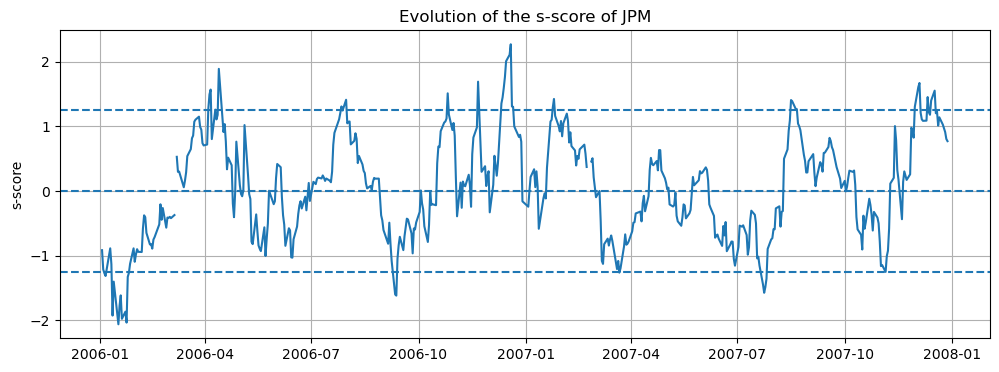

In [37]:
s_JPM, params = plot_s_score(
    ticker="JPM",
    returns=returns_full,            # seu DataFrame de retornos (2005+ para dar lookback)
    window_pca=252,             # PCA anual
    n_factors=15,               # como você já usa
    window_ou=60,               # janela de estimação do OU
    start="2006-01-01",
    end="2007-12-31"
)

### PNL fator PCA

In [32]:
# --- helper para fabricar fatores PCA (eig1..eig_m) a partir dos seus autovetores já calculados ---
def compute_pca_factor_returns(returns: pd.DataFrame, eigen_vec: np.ndarray, sigma: pd.Series, n_factors: int = 6):
    """
    returns: DataFrame [date x tickers] de retornos das ações (sem NaN nas colunas escolhidas)
    eigen_vec: matriz (n_assets x n_assets) com autovetores por coluna (ordenados por maior autovalor)
    sigma: desvio-padrão cross-sectional por ativo (Series indexada pelos tickers)
    n_factors: quantos fatores (PCs) extrair
    -> DataFrame [date x eig1..eig_m]
    """
    F = pd.DataFrame(index=returns.index)
    # garante alinhamento de índices/ordem de colunas
    tickers = list(returns.columns)
    for j in range(n_factors):
        vj = pd.Series(eigen_vec[:, j], index=tickers)     # autovetor j
        wj = vj / sigma                                    # eigen-weights ~ 1/σ
        wj = wj / wj.abs().sum()                           # |w|=1 (controle de alavancagem)
        F[f"eig{j+1}"] = returns.dot(wj)
    return F


In [33]:
# PCA rolling (recalcula eigenvectors com janela 1_win)
def compute_pca_factors_rolling(returns: pd.DataFrame, window_pca=252, n_factors=15):
    """
    Para cada data t (a partir de window_pca), calcula PCA na janela [t-window_pca, t),
    gera eigen-weights (vj/sigma_j) e constrói fatores eig1..eig_m para o dia t.
    """
    dates   = returns.index
    tickers = returns.columns
    F = pd.DataFrame(index=dates, columns=[f"eig{i+1}" for i in range(n_factors)], dtype=float)

    for i in range(window_pca, len(dates)):
        t0, t = dates[i-window_pca:i], dates[i]
        Rw = returns.loc[t0, tickers]
        # padroniza na janela
        Zw = (Rw - Rw.mean()) / Rw.std(ddof=1)
        Zw = Zw.dropna(axis=1, how='any')   # ativos com buracos saem desta janela
        if Zw.shape[1] < n_factors + 1:
            continue

        C = Zw.corr()
        evals, evecs = np.linalg.eigh(C.values)
        idx = np.argsort(evals)[::-1]
        evecs = evecs[:, idx]  # autovetores por coluna

        sigma_w = Rw[Zw.columns].std(ddof=1)

        # pesos e fatores no dia t (usam retornos do dia t)
        Rt = returns.loc[t, Zw.columns]
        if Rt.isnull().any():
            continue

        for j in range(n_factors):
            vj = pd.Series(evecs[:, j], index=Zw.columns)
            wj = vj / sigma_w
            wj = wj / wj.abs().sum()
            F.loc[t, f"eig{j+1}"] = float(Rt.dot(wj))

    return F.dropna(how="all")

In [35]:
# Depois de criar returns_full e returns_spy_full, padronize os índices
returns_full.index     = pd.to_datetime(returns_full.index).tz_localize(None)
returns_spy_full.index = pd.to_datetime(returns_spy_full.index).tz_localize(None)

returns_full     = returns_full.sort_index()
returns_spy_full = returns_spy_full.sort_index()

# escolha quantos PCs quer alimentar o modelo
NUM_PC = 15
# F_full = compute_pca_factor_returns(
#     returns=returns_full,
#     eigen_vec=eigen_vec_full,
#     sigma=sigma_full,
#     n_factors=NUM_PC
# )

F_full_roll = compute_pca_factors_rolling(returns_full, window_pca=252, n_factors=NUM_PC)

modified_returns_full = pd.concat([returns_full, F_full_roll], axis=1).dropna()
spy = returns_spy_full.copy()
spy.name = "SPY"
returns_all_full = modified_returns_full.join(spy, how="inner")

# Garanta que não está vazio
print("modified_returns_full:", modified_returns_full.shape)
print("SPY:", spy.shape)
print("returns_all_full:", returns_all_full.shape)   # <- deve ter muitas linhas!
assert len(returns_all_full) > 0, "returns_all_full ficou vazio após o join"


modified_returns_full: (2513, 330)
SPY: (2765, 1)
returns_all_full: (2513, 331)


In [41]:
def n_pca_portfolio_spy(modified_returns: pd.DataFrame,
                        returns_all: pd.DataFrame,
                        num_pc: int = 6,
                        l_win: int = 252,
                        s_win: int = 60):
    """
    modified_returns: DataFrame com [ações] + colunas eig1..eig{num_pc}
    returns_all:     modified_returns + coluna 'SPY' (para comparação)
    num_pc:          quantidade de PCs a usar
    l_win:           lookback "longo" p/ começar (primeiros l_win dias não operam)
    s_win:           janela curta de regressões (para padronizar e estimar a cada t)

    Retorna:
      cumret_algo (Series), s_scores (DataFrame)
    """

    # ----- nomes dos PCs -----
    pcs = [f"eig{i+1}" for i in range(num_pc)]

    # ----- universo de ações (tudo que não é SPY nem PCs) -----
    stocks = [c for c in returns_all.columns if c not in (["SPY"] + pcs)]

    # índices de datas utilizáveis (começando após l_win)
    usable_index = returns_all.iloc[l_win:].index

    # matrizes para scores e betas
    s_scores = pd.DataFrame(index=usable_index, columns=stocks, dtype=float)
    betas    = pd.DataFrame(index=usable_index, columns=stocks, dtype=object)  # guardo vetor (coef_) por ação

    for t in usable_index:
        # janela curta até t
        tmp_ret = modified_returns.loc[:t].iloc[-s_win:].copy()
        std = tmp_ret.std(ddof=1).replace(0, np.nan)
        
        # padroniza por coluna na janela (z-score)
        tmp_ret = (tmp_ret - tmp_ret.mean()) / std
        if tmp_ret[pcs].isnull().any().any():
            continue
            
        # dataframe com parâmetros OU por ação
        ou_cols = ['a','b','Var(zeta)','kappa','m','sigma','sigma_eq']
        ou_params = pd.DataFrame(index=stocks, columns=ou_cols, dtype=float)

        # matrizes para regressão 1 (ação ~ PCs)
        X = tmp_ret[pcs].values  # (s_win x num_pc)

        for stock in stocks:
            y = tmp_ret[stock].values  # (s_win,)

            if np.isnan(y).any() or np.isnan(X).any():
                continue  # pula se houver NaN nessa janela

            # 1) Regressão linear: retorno da ação ~ retornos dos PCs
            model1 = LinearRegression().fit(X, y)
            betas.loc[t, stock] = model1.coef_  # vetor (num_pc,)

            epsilon = y - model1.predict(X)

            # 2) Regressão do passeio acumulado (Xk) p/ extrair (a,b) do OU
            Xk = epsilon.cumsum()
            if len(Xk) < 2:
                continue

            X_ou = Xk[:-1].reshape(-1, 1)
            y_ou = Xk[1:]
            model2 = LinearRegression().fit(X_ou, y_ou)
            a = float(model2.intercept_)
            b = float(model2.coef_[0])
            zeta = y_ou - model2.predict(X_ou)
            
            # descarte/clip de casos não-estacionários ou mal definidos
            if not np.isfinite(a) or not np.isfinite(b):
                continue
            # b deve estar estritamente dentro (-1,1)
            if abs(b) >= 0.999:
                continue
            
            var_zeta = float(np.var(zeta, ddof=1))
            if not np.isfinite(var_zeta) or var_zeta <= 0:
                continue
            
            den = max(1.0 - b**2, 1e-8)                # evita <=0
            b_clipped = np.clip(b, 1e-6, 0.999)        # evita log<=0
            
            kappa    = -np.log(b_clipped) * 252.0
            m        = a / (1.0 - b_clipped)
            sigma_eq = np.sqrt(var_zeta / den)
            sigma    = np.sqrt(var_zeta * 2.0 * kappa / den)

            # só aceita se reverte suficientemente rápido
            if kappa > (252 / 30):  # ~ meia-vida < ~1 mês
                ou_params.loc[stock] = [a, b, var_zeta, kappa, m, sigma, sigma_eq]

        # S-score
        with np.errstate(divide='ignore', invalid='ignore'):
            m_bar = ou_params['a']/(1.0 - ou_params['b']) - (ou_params['a'].mean()/(1.0 - ou_params['b'].mean()))
            s = -m_bar / ou_params['sigma_eq']
        s_scores.loc[t] = s

    # limpa datas/linhas sem score completo
    null_idx = s_scores.index[s_scores.isnull().all(axis=1)]
    s_scores = s_scores.drop(index=null_idx)
    betas = betas.drop(index=null_idx)

    # ===== Regras de posição por ativo (threshold de S-score) =====
    algo_pos = pd.DataFrame(index=s_scores.index, columns=stocks, dtype=float)
    for s in stocks:
        pos = 0
        col = []
        for dt in s_scores.index:
            score = s_scores.loc[dt, s]

            # abrir posições
            if score > 1.25:
                pos = -1
            elif score < -1.25:
                pos = 1
            # fechar posições (bandas internas)
            elif score < 0.5 and pos == -1:
                pos = 0
            elif score > -0.5 and pos == 1:
                pos = 0
            col.append(pos)
        algo_pos[s] = col

    # ===== Pesos iguais entre longs e entre shorts (dentro do dia) =====
    algo_weights = pd.DataFrame(index=algo_pos.index, columns=stocks, dtype=float)
    
    for dt in algo_pos.index:
        tmp = algo_pos.loc[dt].astype(float).copy()
        # normaliza separadamente
        longs  = tmp > 0
        shorts = tmp < 0
        n_long = longs.sum()
        n_short = shorts.sum()
    
        if n_long > 0:
            tmp.loc[longs] =  1.0 / float(n_long)
        else:
            tmp.loc[longs] = 0.0
    
        if n_short > 0:
            tmp.loc[shorts] = -1.0 / float(n_short)
        else:
            tmp.loc[shorts] = 0.0
    
        # zere explícito para quem ficou neutro
        tmp.loc[~longs & ~shorts] = 0.0
    
        algo_weights.loc[dt] = tmp.values

    # ===== Hedge nos PCs (neutralizar exposição média via betas) =====
    # soma (beta * peso) por data -> vetor num_pc, com sinal invertido para hedge
    beta_bar = betas.apply(lambda col: col.map(
        lambda v: np.array(v) if isinstance(v, (list, np.ndarray)) else np.zeros(num_pc)))
    
    # produto linha-a-linha: (betas * pesos) somado no eixo ações
    hedge_vec = []
    for dt in algo_weights.index:
        b_dt = np.vstack(beta_bar.loc[dt, stocks].values) if len(stocks) else np.zeros((0, num_pc))
        w_dt = algo_weights.loc[dt, stocks].values.reshape(-1, 1)
        expo = (b_dt * w_dt).sum(axis=0)  # (num_pc,)
        hedge_vec.append(-expo)          # sinal p/ neutralizar
    hedge = pd.DataFrame(hedge_vec, index=algo_weights.index, columns=pcs)

    # junta pesos de ações + pesos de fatores
    w_all = pd.concat([algo_weights, hedge], axis=1)
    # normaliza a exposição bruta por linha
    gross = w_all.abs().sum(axis=1).replace(0, np.nan)
    w_all = w_all.div(gross, axis=0).fillna(0.0)  # cap ∑|w|=1

    # ===== Retorno diário do algoritmo =====
    
    # custo de transação = 5 bps (0.0005)
    eps = 0.0005
    # usa pesos defasados (executa na abertura/fechamento seguinte)
    w_shift = w_all.shift().bfill()
    rets = modified_returns.loc[w_shift.index, stocks + pcs]
    # retorno bruto
    ret_gross  = (rets * w_shift[rets.columns]).sum(axis=1)
    # turnover = soma das trocas absolutas de peso
    turnover = (w_all - w_all.shift()).abs().sum(axis=1).fillna(0.0)
    # retorno líquido (com custo)
    ret_net = ret_gross - eps * turnover

    cumret_algo = (1.0 + ret_net.fillna(0)).cumprod()

    # ===== Comparação: SPY =====
    spy = returns_all.loc[cumret_algo.index, "SPY"].fillna(0.0)
    cumret_spy = (1.0 + spy).cumprod()

    # ----- Plot -----
    plt.figure(figsize=(18,6))
    plt.grid(True)
    plt.plot(cumret_algo.index, cumret_algo, label='Algo (PCA-OU)')
    plt.plot(cumret_spy.index,  cumret_spy,  label='SPY')
    plt.legend()
    plt.title(f'Estratégia PCA/OU vs SPY  |  PCs={num_pc}, l_win={l_win}, s_win={s_win}')
    plt.show()

    return cumret_algo, s_scores

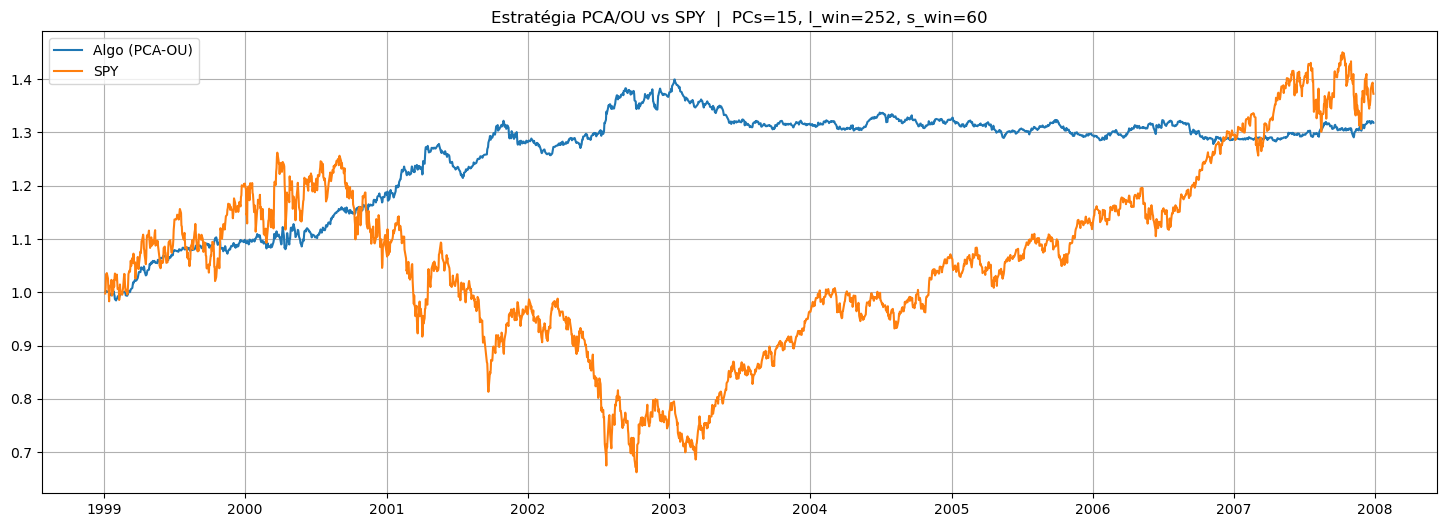

In [43]:
cum_algo, s_scores = n_pca_portfolio_spy(
    modified_returns=modified_returns_full,
    returns_all=returns_all_full,
    num_pc=15,
    l_win=252,   # ~ 1 ano
    s_win=60     # ~ 3 meses
)


In [45]:
def stats_from_returns(ret):
    ann = 252
    cagr = (1+ret).prod()**(ann/len(ret)) - 1
    vol  = ret.std(ddof=1) * np.sqrt(ann)
    sharpe = cagr/vol if vol>0 else np.nan
    # max drawdown
    cum = (1+ret).cumprod()
    peak = cum.cummax()
    dd = (cum/peak - 1).min()
    return {"CAGR": cagr, "Vol": vol, "Sharpe": sharpe, "MaxDD": dd}

ret_series = cum_algo.pct_change().dropna()
print(stats_from_returns(ret_series))

{'CAGR': 0.03120361313230724, 'Vol': 0.04254629098930594, 'Sharpe': 0.7334038386601149, 'MaxDD': -0.08658724737522616}
